In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/train-images-idx3-ubyte


In [3]:
train_path = '/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv'
test_path = '/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Separate labels and pixels
y_full = train_df['label'].values
X_full = train_df.drop('label', axis=1).values.astype(np.float32)

y_test = test_df['label'].values
X_test = test_df.drop('label', axis=1).values.astype(np.float32)

# Normalize pixel values to [0, 1]
X_full /= 255.0
X_test /= 255.0

# Already flattened (784 columns), so no reshape needed

# Stratified 80/20 train/val split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.20, random_state=SEED, stratify=y_full
)

print(f"Train samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Feature dimension: {X_train.shape[1]}")

print("\nClass distribution (train):")
print(pd.Series(y_train).value_counts().sort_index())

print("\nClass distribution (validation):")
print(pd.Series(y_val).value_counts().sort_index())

print("\nClass distribution (test):")
print(pd.Series(y_test).value_counts().sort_index())

Train samples: 48000
Validation samples: 12000
Test samples: 10000
Feature dimension: 784

Class distribution (train):
0    4800
1    4800
2    4800
3    4800
4    4800
5    4800
6    4800
7    4800
8    4800
9    4800
Name: count, dtype: int64

Class distribution (validation):
0    1200
1    1200
2    1200
3    1200
4    1200
5    1200
6    1200
7    1200
8    1200
9    1200
Name: count, dtype: int64

Class distribution (test):
0    1000
1    1000
2    1000
3    1000
4    1000
5    1000
6    1000
7    1000
8    1000
9    1000
Name: count, dtype: int64


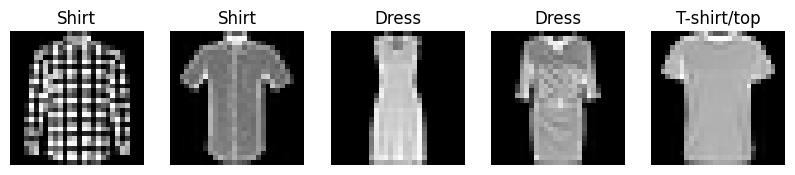

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(class_names[y_train[i]])
    ax.axis('off')
plt.show()

In [5]:
class NumpyMLP:
    def __init__(self, input_dim=784, hidden_dim=64, output_dim=10, seed=42):
        rng = np.random.default_rng(seed)
        # He init for the ReLU layer, small-scale init for the output layer
        self.W1 = rng.standard_normal((input_dim, hidden_dim)) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros(hidden_dim)
        self.W2 = rng.standard_normal((hidden_dim, output_dim)) * np.sqrt(1.0 / hidden_dim)
        self.b2 = np.zeros(output_dim)

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return (Z > 0).astype(np.float32)

    def softmax(self, Z):
        Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
        expZ = np.exp(Z_shifted)
        return expZ / np.sum(expZ, axis=1, keepdims=True)

    def forward(self, X):
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = self.softmax(self.Z2)
        return self.A2

    def compute_loss(self, y_pred, y_true_onehot):
        m = y_true_onehot.shape[0]
        eps = 1e-12
        return -np.sum(y_true_onehot * np.log(y_pred + eps)) / m

    def backward(self, X, y_true_onehot):
        m = X.shape[0]
        dZ2 = (self.A2 - y_true_onehot) / m          # softmax + CE gradient combines nicely
        dW2 = self.A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0)
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * self.relu_derivative(self.Z1)
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0)
        return dW1, db1, dW2, db2

    def update(self, grads, lr):
        dW1, db1, dW2, db2 = grads
        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        self.W2 -= lr * dW2
        self.b2 -= lr * db2

def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

Epoch 1/20 - Loss: 1.5178
Epoch 2/20 - Loss: 0.9786
Epoch 3/20 - Loss: 0.7931
Epoch 4/20 - Loss: 0.7572
Epoch 5/20 - Loss: 0.7881
Epoch 6/20 - Loss: 0.6618
Epoch 7/20 - Loss: 0.5790
Epoch 8/20 - Loss: 0.5899
Epoch 9/20 - Loss: 0.5247
Epoch 10/20 - Loss: 0.5185
Epoch 11/20 - Loss: 0.4977
Epoch 12/20 - Loss: 0.6610
Epoch 13/20 - Loss: 0.5638
Epoch 14/20 - Loss: 0.4620
Epoch 15/20 - Loss: 0.4552
Epoch 16/20 - Loss: 0.4481
Epoch 17/20 - Loss: 0.4034
Epoch 18/20 - Loss: 0.4591
Epoch 19/20 - Loss: 0.4184
Epoch 20/20 - Loss: 0.4104


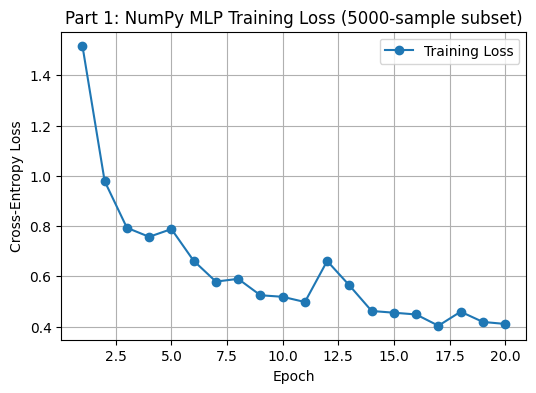

In [6]:
np.random.seed(SEED)
subset_idx = np.random.choice(len(X_train), 5000, replace=False)
X_sub = X_train[subset_idx]
y_sub = y_train[subset_idx]
y_sub_oh = one_hot(y_sub)

model = NumpyMLP(seed=SEED)

lr = 0.5
batch_size = 64
epochs = 20
n_samples = X_sub.shape[0]
loss_history = []

for epoch in range(epochs):
    perm = np.random.permutation(n_samples)
    X_shuffled, y_shuffled = X_sub[perm], y_sub_oh[perm]

    epoch_losses = []
    for start in range(0, n_samples, batch_size):
        X_batch = X_shuffled[start:start+batch_size]
        y_batch = y_shuffled[start:start+batch_size]

        y_pred = model.forward(X_batch)
        epoch_losses.append(model.compute_loss(y_pred, y_batch))
        grads = model.backward(X_batch, y_batch)
        model.update(grads, lr)

    avg_loss = np.mean(epoch_losses)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

plt.figure(figsize=(6,4))
plt.plot(range(1, epochs+1), loss_history, marker='o', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Part 1: NumPy MLP Training Loss (5000-sample subset)')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

check_model = NumpyMLP(seed=SEED)  # fresh, untrained

X_check = X_sub[:64]
y_check = y_sub[:64]
y_check_oh = one_hot(y_check)

# NumPy forward + backward
y_pred_np = check_model.forward(X_check)
loss_np = check_model.compute_loss(y_pred_np, y_check_oh)
dW1_np, db1_np, dW2_np, db2_np = check_model.backward(X_check, y_check_oh)

# Identical PyTorch model, weights copied directly from the NumPy model
torch_model = nn.Sequential(nn.Linear(784, 64), nn.ReLU(), nn.Linear(64, 10))
with torch.no_grad():
    torch_model[0].weight.copy_(torch.tensor(check_model.W1.T, dtype=torch.float32))
    torch_model[0].bias.copy_(torch.tensor(check_model.b1, dtype=torch.float32))
    torch_model[2].weight.copy_(torch.tensor(check_model.W2.T, dtype=torch.float32))
    torch_model[2].bias.copy_(torch.tensor(check_model.b2, dtype=torch.float32))

X_check_t = torch.tensor(X_check, dtype=torch.float32)
y_check_t = torch.tensor(y_check, dtype=torch.long)

logits = torch_model(X_check_t)
loss_torch = F.cross_entropy(logits, y_check_t)  # does log_softmax + NLL internally
loss_torch.backward()

dW1_torch = torch_model[0].weight.grad.numpy().T
db1_torch = torch_model[0].bias.grad.numpy()
dW2_torch = torch_model[2].weight.grad.numpy().T
db2_torch = torch_model[2].bias.grad.numpy()

print(f"NumPy loss:   {loss_np:.6f}")
print(f"PyTorch loss: {loss_torch.item():.6f}")
print(f"Max abs diff dW1: {np.max(np.abs(dW1_np - dW1_torch)):.2e}")
print(f"Max abs diff db1: {np.max(np.abs(db1_np - db1_torch)):.2e}")
print(f"Max abs diff dW2: {np.max(np.abs(dW2_np - dW2_torch)):.2e}")
print(f"Max abs diff db2: {np.max(np.abs(db2_np - db2_torch)):.2e}")

NumPy loss:   2.405856
PyTorch loss: 2.405856
Max abs diff dW1: 1.64e-08
Max abs diff db1: 4.25e-09
Max abs diff dW2: 3.42e-08
Max abs diff db2: 5.16e-09


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)

Using device: cuda


In [9]:
class MLP(nn.Module):
    def __init__(self, activation='relu'):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        acts = {
            'sigmoid': nn.Sigmoid(),
            'tanh': nn.Tanh(),
            'relu': nn.ReLU(),
            'leaky_relu': nn.LeakyReLU(0.01)
        }
        self.act = acts[activation]

    def forward(self, x):
        h1 = self.act(self.fc1(x))
        h2 = self.act(self.fc2(h1))
        out = self.fc3(h2)
        return out, h1  # h1 returned for dead-unit / gradient analysis later

In [10]:
def train_model(activation, epochs=20, lr=1e-3, batch_size=128, seed=SEED):
    torch.manual_seed(seed)  # identical initial weights across all four runs
    model = MLP(activation).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t)
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    val_losses = []
    grad_history = []  # mean |gradient| of fc1.weight, per epoch

    for epoch in range(epochs):
        model.train()
        epoch_grads = []
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits, _ = model(xb)
            loss = F.cross_entropy(logits, yb)
            loss.backward()
            epoch_grads.append(model.fc1.weight.grad.abs().mean().item())
            optimizer.step()
        grad_history.append(np.mean(epoch_grads))

        model.eval()
        with torch.no_grad():
            val_logits, _ = model(X_val_t)
            val_loss = F.cross_entropy(val_logits, y_val_t).item()
        val_losses.append(val_loss)

        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(f"[{activation}] Epoch {epoch+1}/{epochs} - Val Loss: {val_loss:.4f} - Mean|grad fc1|: {grad_history[-1]:.6e}")

    return model, val_losses, grad_history

In [11]:
activations = ['sigmoid', 'tanh', 'relu', 'leaky_relu']
results = {}

for act in activations:
    print(f"\n=== Training with {act} ===")
    model, val_losses, grad_history = train_model(act)
    results[act] = {'model': model, 'val_losses': val_losses, 'grad_history': grad_history}


=== Training with sigmoid ===
[sigmoid] Epoch 1/20 - Val Loss: 0.6356 - Mean|grad fc1|: 1.064426e-04
[sigmoid] Epoch 5/20 - Val Loss: 0.3722 - Mean|grad fc1|: 3.364891e-04
[sigmoid] Epoch 10/20 - Val Loss: 0.3296 - Mean|grad fc1|: 3.858427e-04
[sigmoid] Epoch 15/20 - Val Loss: 0.3257 - Mean|grad fc1|: 4.222938e-04
[sigmoid] Epoch 20/20 - Val Loss: 0.3150 - Mean|grad fc1|: 4.661495e-04

=== Training with tanh ===
[tanh] Epoch 1/20 - Val Loss: 0.4254 - Mean|grad fc1|: 8.673378e-04
[tanh] Epoch 5/20 - Val Loss: 0.3326 - Mean|grad fc1|: 9.876194e-04
[tanh] Epoch 10/20 - Val Loss: 0.3130 - Mean|grad fc1|: 9.421441e-04
[tanh] Epoch 15/20 - Val Loss: 0.3068 - Mean|grad fc1|: 9.362800e-04
[tanh] Epoch 20/20 - Val Loss: 0.3074 - Mean|grad fc1|: 9.804781e-04

=== Training with relu ===
[relu] Epoch 1/20 - Val Loss: 0.4567 - Mean|grad fc1|: 9.515319e-04
[relu] Epoch 5/20 - Val Loss: 0.3477 - Mean|grad fc1|: 9.920104e-04
[relu] Epoch 10/20 - Val Loss: 0.3195 - Mean|grad fc1|: 9.569093e-04
[relu] 

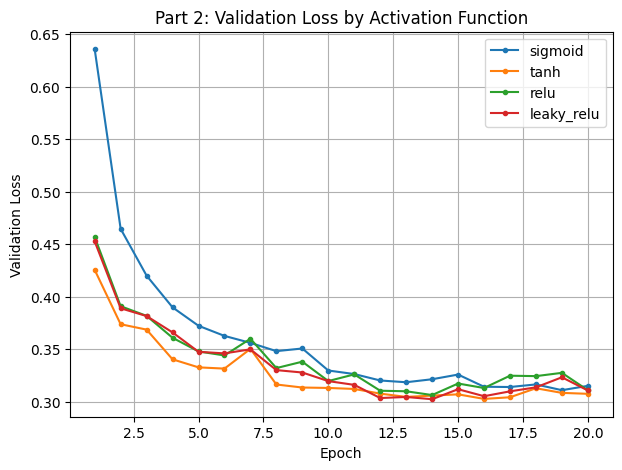

In [12]:
plt.figure(figsize=(7,5))
for act in activations:
    plt.plot(range(1, 21), results[act]['val_losses'], marker='o', markersize=3, label=act)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Part 2: Validation Loss by Activation Function')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
for act in ['sigmoid', 'relu']:
    g = results[act]['grad_history']
    print(f"{act}: epoch 1 mean|grad fc1| = {g[0]:.3e}   |   final epoch mean|grad fc1| = {g[-1]:.3e}")

sigmoid: epoch 1 mean|grad fc1| = 1.064e-04   |   final epoch mean|grad fc1| = 4.661e-04
relu: epoch 1 mean|grad fc1| = 9.515e-04   |   final epoch mean|grad fc1| = 1.059e-03


In [14]:
relu_model = results['relu']['model']
relu_model.eval()
with torch.no_grad():
    val_batch = X_val_t[:256]
    _, h1 = relu_model(val_batch)
    dead_mask = (h1 == 0).all(dim=0)  # unit fires zero for every sample in this batch
    pct_dead = dead_mask.float().mean().item() * 100

print(f"Percentage of dead units in fc1 (128 units), val batch of 256: {pct_dead:.2f}%")

Percentage of dead units in fc1 (128 units), val batch of 256: 9.38%


Vanishing gradients: The sigmoid network's mean absolute gradient in the first hidden layer was roughly 9 times smaller than ReLU's at epoch 1 (1.06e-4 vs. 9.52e-4), consistent with sigmoid's saturating regions producing near-zero derivatives. The gap narrowed over training as the adaptive Adam optimizer compensated and weights moved away from saturation, but sigmoid's gradient never matched ReLU's magnitude, which likely explains why it converged to a slightly higher validation loss overall.

Dead ReLU units: 9.38% of the 128 hidden units in the first ReLU layer output zero for every sample in the validation batch, meaning roughly 1 in 10 units contributed nothing to the network's representational capacity. This is a moderate, expected level of dead units for this learning rate and initialization, not severe enough to noticeably hurt performance, but it illustrates why leaky ReLU (which allows a small negative gradient) is often preferred to prevent units from getting permanently stuck.

In [15]:
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)
y_train_oh_t = torch.tensor(one_hot(y_train), dtype=torch.float32).to(device)

class ClassifierMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        h1 = self.relu(self.fc1(x))
        h2 = self.relu(self.fc2(h1))
        out = self.fc3(h2)
        return out  # raw logits

def accuracy(logits, y_true):
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

In [16]:
torch.manual_seed(SEED)
model_ce = ClassifierMLP().to(device)
optimizer_ce = torch.optim.Adam(model_ce.parameters(), lr=1e-3)

train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True)

epochs = 20
ce_train_losses = []

for epoch in range(epochs):
    model_ce.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer_ce.zero_grad()
        logits = model_ce(xb)
        loss = F.cross_entropy(logits, yb)
        loss.backward()
        optimizer_ce.step()
        batch_losses.append(loss.item())
    ce_train_losses.append(np.mean(batch_losses))
    if (epoch+1) % 5 == 0:
        print(f"[CE] Epoch {epoch+1}/{epochs} - Train Loss: {ce_train_losses[-1]:.4f}")

model_ce.eval()
with torch.no_grad():
    test_logits_ce = model_ce(X_test_t)
    ce_test_acc = accuracy(test_logits_ce, y_test_t)
print(f"\nCross-Entropy Test Accuracy: {ce_test_acc*100:.2f}%")

[CE] Epoch 5/20 - Train Loss: 0.3410
[CE] Epoch 10/20 - Train Loss: 0.2786
[CE] Epoch 15/20 - Train Loss: 0.2366
[CE] Epoch 20/20 - Train Loss: 0.2066

Cross-Entropy Test Accuracy: 89.19%


In [17]:
torch.manual_seed(SEED)  # identical initial weights
model_mse = ClassifierMLP().to(device)
optimizer_mse = torch.optim.Adam(model_mse.parameters(), lr=1e-3)

train_ds_oh = torch.utils.data.TensorDataset(X_train_t, y_train_oh_t)
train_loader_oh = torch.utils.data.DataLoader(train_ds_oh, batch_size=128, shuffle=True)

mse_train_losses = []

for epoch in range(epochs):
    model_mse.train()
    batch_losses = []
    for xb, yb_oh in train_loader_oh:
        optimizer_mse.zero_grad()
        logits = model_mse(xb)
        probs = F.softmax(logits, dim=1)  # MSE compared against probabilities, not raw logits
        loss = F.mse_loss(probs, yb_oh)
        loss.backward()
        optimizer_mse.step()
        batch_losses.append(loss.item())
    mse_train_losses.append(np.mean(batch_losses))
    if (epoch+1) % 5 == 0:
        print(f"[MSE] Epoch {epoch+1}/{epochs} - Train Loss: {mse_train_losses[-1]:.4f}")

model_mse.eval()
with torch.no_grad():
    test_logits_mse = model_mse(X_test_t)
    mse_test_acc = accuracy(test_logits_mse, y_test_t)
print(f"\nMSE Test Accuracy: {mse_test_acc*100:.2f}%")

[MSE] Epoch 5/20 - Train Loss: 0.0180
[MSE] Epoch 10/20 - Train Loss: 0.0152
[MSE] Epoch 15/20 - Train Loss: 0.0134
[MSE] Epoch 20/20 - Train Loss: 0.0119

MSE Test Accuracy: 88.78%


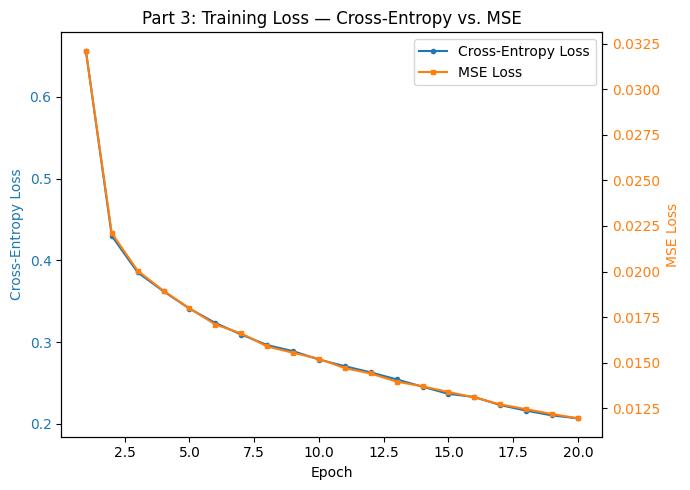

In [18]:
fig, ax1 = plt.subplots(figsize=(7,5))
ax1.plot(range(1, epochs+1), ce_train_losses, color='tab:blue', marker='o', markersize=3, label='Cross-Entropy Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(range(1, epochs+1), mse_train_losses, color='tab:orange', marker='s', markersize=3, label='MSE Loss')
ax2.set_ylabel('MSE Loss', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Part 3: Training Loss — Cross-Entropy vs. MSE')
fig.tight_layout()
plt.show()

In [19]:
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

diabetes = load_diabetes()
X_reg, y_reg = diabetes.data, diabetes.target

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=SEED
)

scaler_X = StandardScaler().fit(X_reg_train)
X_reg_train = scaler_X.transform(X_reg_train)
X_reg_test = scaler_X.transform(X_reg_test)

X_reg_train_t = torch.tensor(X_reg_train, dtype=torch.float32).to(device)
y_reg_train_t = torch.tensor(y_reg_train, dtype=torch.float32).view(-1,1).to(device)
X_reg_test_t = torch.tensor(X_reg_test, dtype=torch.float32).to(device)
y_reg_test_t = torch.tensor(y_reg_test, dtype=torch.float32).view(-1,1).to(device)

class RegressionMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

torch.manual_seed(SEED)
reg_model = RegressionMLP(X_reg_train.shape[1]).to(device)
reg_optimizer = torch.optim.Adam(reg_model.parameters(), lr=1e-2)

for epoch in range(200):
    reg_model.train()
    reg_optimizer.zero_grad()
    preds = reg_model(X_reg_train_t)
    loss = F.mse_loss(preds, y_reg_train_t)
    loss.backward()
    reg_optimizer.step()
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/200 - Train MSE: {loss.item():.2f}")

reg_model.eval()
with torch.no_grad():
    test_preds = reg_model(X_reg_test_t).cpu().numpy()

test_mse = mean_squared_error(y_reg_test, test_preds)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_reg_test, test_preds)

print(f"\nTabular Regression (Diabetes dataset) — Test set:")
print(f"MSE:  {test_mse:.2f}")
print(f"RMSE: {test_rmse:.2f}")
print(f"MAE:  {test_mae:.2f}")

Epoch 50/200 - Train MSE: 4087.89
Epoch 100/200 - Train MSE: 2793.96
Epoch 150/200 - Train MSE: 2611.19
Epoch 200/200 - Train MSE: 2523.61

Tabular Regression (Diabetes dataset) — Test set:
MSE:  2794.99
RMSE: 52.87
MAE:  42.67


Cross-entropy converges faster than mean squared error for classification because its gradient with respect to the logits, when combined with softmax, simplifies to (predicted_probability − true_label)  a signal that stays large whenever the model is confidently wrong, regardless of how saturated the softmax output is. MSE's gradient instead includes an extra factor from the softmax derivative, which shrinks toward zero as probabilities approach 0 or 1, so a confidently wrong prediction produces a weaker learning signal under MSE than under cross-entropy, slowing convergence. In this experiment, cross-entropy reached 89.19% test accuracy versus MSE's 88.78% over the same 20 epochs, consistent with cross-entropy extracting a stronger gradient signal per update.

In [20]:
import time

def train_with_optimizer(optimizer_name, lr, epochs=30, batch_size=128, seed=SEED):
    torch.manual_seed(seed)
    model = ClassifierMLP().to(device)

    if optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == 'sgd_momentum':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == 'rmsprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t)
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    train_losses = []
    epochs_to_85 = None

    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_losses.append(np.mean(batch_losses))

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_acc = accuracy(val_logits, y_val_t)

        if epochs_to_85 is None and val_acc >= 0.85:
            epochs_to_85 = epoch + 1

    elapsed = time.time() - start_time
    final_val_acc = val_acc

    return {
        'train_losses': train_losses,
        'epochs_to_85': epochs_to_85 if epochs_to_85 is not None else '>' + str(epochs),
        'final_val_acc': final_val_acc,
        'wall_clock': elapsed
    }

In [21]:
shared_lr = 0.01
optimizers = ['sgd', 'sgd_momentum', 'rmsprop', 'adam']
results_shared = {}

for opt in optimizers:
    print(f"Training {opt} @ lr={shared_lr}...")
    results_shared[opt] = train_with_optimizer(opt, lr=shared_lr)

print("\n--- Same Learning Rate (0.01) ---")
for opt in optimizers:
    r = results_shared[opt]
    print(f"{opt}: epochs_to_85={r['epochs_to_85']}, final_val_acc={r['final_val_acc']*100:.2f}%, time={r['wall_clock']:.2f}s")

Training sgd @ lr=0.01...
Training sgd_momentum @ lr=0.01...
Training rmsprop @ lr=0.01...
Training adam @ lr=0.01...

--- Same Learning Rate (0.01) ---
sgd: epochs_to_85=23, final_val_acc=84.99%, time=22.19s
sgd_momentum: epochs_to_85=4, final_val_acc=88.79%, time=22.61s
rmsprop: epochs_to_85=4, final_val_acc=85.37%, time=25.17s
adam: epochs_to_85=2, final_val_acc=87.75%, time=26.62s


In [22]:
tuned_lrs = {
    'sgd': 0.1,
    'sgd_momentum': 0.05,
    'rmsprop': 0.001,
    'adam': 0.001
}
results_tuned = {}

for opt in optimizers:
    print(f"Training {opt} @ lr={tuned_lrs[opt]}...")
    results_tuned[opt] = train_with_optimizer(opt, lr=tuned_lrs[opt])

print("\n--- Tuned Learning Rate ---")
for opt in optimizers:
    r = results_tuned[opt]
    print(f"{opt}: lr={tuned_lrs[opt]}, epochs_to_85={r['epochs_to_85']}, final_val_acc={r['final_val_acc']*100:.2f}%, time={r['wall_clock']:.2f}s")

Training sgd @ lr=0.1...
Training sgd_momentum @ lr=0.05...
Training rmsprop @ lr=0.001...
Training adam @ lr=0.001...

--- Tuned Learning Rate ---
sgd: lr=0.1, epochs_to_85=4, final_val_acc=87.78%, time=22.37s
sgd_momentum: lr=0.05, epochs_to_85=2, final_val_acc=87.77%, time=23.02s
rmsprop: lr=0.001, epochs_to_85=2, final_val_acc=88.35%, time=24.70s
adam: lr=0.001, epochs_to_85=2, final_val_acc=89.37%, time=25.76s


In [23]:
table_rows = []
for opt in optimizers:
    r_shared = results_shared[opt]
    r_tuned = results_tuned[opt]
    table_rows.append({
        'Optimiser': opt,
        'Shared LR': shared_lr,
        'Shared: Epochs to 85%': r_shared['epochs_to_85'],
        'Shared: Final Val Acc': f"{r_shared['final_val_acc']*100:.2f}%",
        'Tuned LR': tuned_lrs[opt],
        'Tuned: Epochs to 85%': r_tuned['epochs_to_85'],
        'Tuned: Final Val Acc': f"{r_tuned['final_val_acc']*100:.2f}%",
        'Tuned: Wall-clock (s)': f"{r_tuned['wall_clock']:.2f}"
    })

summary_table = pd.DataFrame(table_rows)
summary_table

,Optimiser,Shared LR,Shared: Epochs to 85%,Shared: Final Val Acc,Tuned LR,Tuned: Epochs to 85%,Tuned: Final Val Acc,Tuned: Wall-clock (s)
0,sgd,0.01,23,84.99%,0.100,4,87.78%,22.37
1,sgd_momentum,0.01,4,88.79%,0.050,2,87.77%,23.02
2,rmsprop,0.01,4,85.37%,0.001,2,88.35%,24.70
3,adam,0.01,2,87.75%,0.001,2,89.37%,25.76


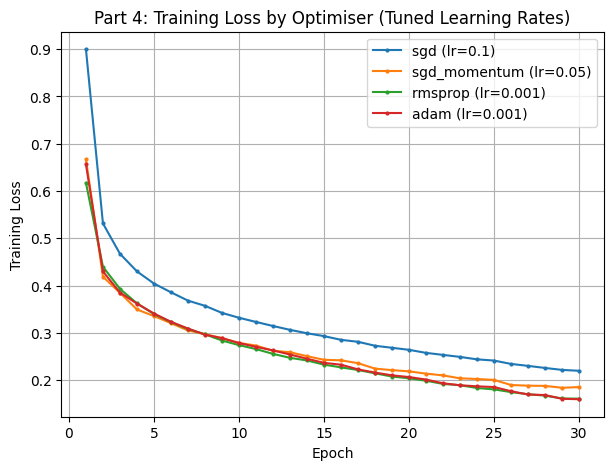

In [24]:
plt.figure(figsize=(7,5))
for opt in optimizers:
    plt.plot(range(1, 31), results_tuned[opt]['train_losses'], marker='o', markersize=2, label=f"{opt} (lr={tuned_lrs[opt]})")
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Part 4: Training Loss by Optimiser (Tuned Learning Rates)')
plt.legend()
plt.grid(True)
plt.show()

Given tuned learning rates, I would choose Adam: it reached the 85% validation accuracy threshold in just 2 epochs, matching the fastest optimisers, while achieving the highest final validation accuracy of the four (89.37% vs. 87.77–88.35% for the others). Its per-parameter adaptive learning rates let it converge quickly without requiring the aggressive hand-tuned rate that plain SGD needed (0.1 vs. Adam's 0.001), making it both the strongest and most forgiving choice for this architecture.

In [25]:
class OverfitMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 10)
        )
    def forward(self, x):
        return self.net(x)

np.random.seed(SEED)
overfit_idx = np.random.choice(len(X_train), 2000, replace=False)
X_overfit = X_train_t[overfit_idx]
y_overfit = y_train_t[overfit_idx]

print(f"Overfitting subset size: {X_overfit.shape[0]}")

Overfitting subset size: 2000


In [26]:
torch.manual_seed(SEED)
overfit_model = OverfitMLP().to(device)
optimizer = torch.optim.Adam(overfit_model.parameters(), lr=1e-3)

train_ds = torch.utils.data.TensorDataset(X_overfit, y_overfit)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True)

epochs = 100
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    overfit_model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = overfit_model(xb)
        loss = F.cross_entropy(logits, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    overfit_model.eval()
    with torch.no_grad():
        train_logits = overfit_model(X_overfit)
        train_loss_full = F.cross_entropy(train_logits, y_overfit).item()
        train_acc = accuracy(train_logits, y_overfit)

        val_logits = overfit_model(X_val_t)
        val_loss = F.cross_entropy(val_logits, y_val_t).item()
        val_acc = accuracy(val_logits, y_val_t)

    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc*100:.2f}% - Val Acc: {val_acc*100:.2f}% - Train Loss: {train_loss_full:.4f} - Val Loss: {val_loss:.4f}")

    if train_acc > 0.99 and epoch > 20:
        print(f"\nReached >99% train accuracy at epoch {epoch+1}, continuing to fill out the curve...")

Epoch 10/100 - Train Acc: 88.15% - Val Acc: 80.19% - Train Loss: 0.3336 - Val Loss: 0.5962
Epoch 20/100 - Train Acc: 94.40% - Val Acc: 82.71% - Train Loss: 0.1657 - Val Loss: 0.5780
Epoch 30/100 - Train Acc: 94.40% - Val Acc: 81.52% - Train Loss: 0.1449 - Val Loss: 0.8552
Epoch 40/100 - Train Acc: 98.65% - Val Acc: 83.27% - Train Loss: 0.0449 - Val Loss: 0.8427

Reached >99% train accuracy at epoch 41, continuing to fill out the curve...

Reached >99% train accuracy at epoch 42, continuing to fill out the curve...

Reached >99% train accuracy at epoch 45, continuing to fill out the curve...

Reached >99% train accuracy at epoch 49, continuing to fill out the curve...
Epoch 50/100 - Train Acc: 99.35% - Val Acc: 83.29% - Train Loss: 0.0167 - Val Loss: 1.1546

Reached >99% train accuracy at epoch 50, continuing to fill out the curve...

Reached >99% train accuracy at epoch 51, continuing to fill out the curve...
Epoch 60/100 - Train Acc: 95.20% - Val Acc: 78.96% - Train Loss: 0.1562 - Val

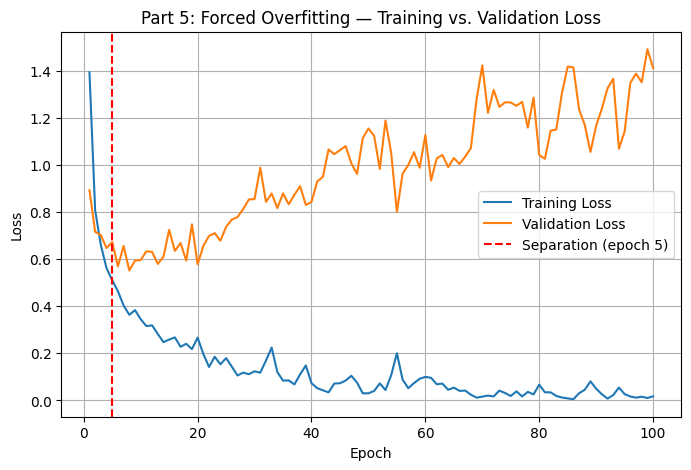

Final train accuracy: 98.95%
Final val accuracy: 82.91%
Generalization gap: 16.04 percentage points
Curves separate around epoch: 5


In [27]:
# Separation point: first epoch where the gap between val and train loss exceeds a threshold
gaps = np.array(val_losses) - np.array(train_losses)
threshold = 0.1  # tune this — pick the epoch where curves visibly diverge
separation_epoch = next((i+1 for i, g in enumerate(gaps) if g > threshold), None)

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_losses, label='Training Loss')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss')
if separation_epoch:
    plt.axvline(separation_epoch, color='red', linestyle='--', label=f'Separation (epoch {separation_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Part 5: Forced Overfitting — Training vs. Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

final_train_acc = train_accs[-1]
final_val_acc = val_accs[-1]
gen_gap = (final_train_acc - final_val_acc) * 100

print(f"Final train accuracy: {final_train_acc*100:.2f}%")
print(f"Final val accuracy: {final_val_acc*100:.2f}%")
print(f"Generalization gap: {gen_gap:.2f} percentage points")
print(f"Curves separate around epoch: {separation_epoch}")

This model exhibits high variance, not high bias. Training accuracy reached 98.95% (crossing 99% at several epochs, e.g. 41, 45, and 50), showing the network has more than enough capacity to fit,even memorize, the 2000-sample training set almost perfectly, which rules out high bias (a high-bias model would fail to fit even the training data well). Meanwhile validation accuracy plateaued around 80–83% and validation loss increased from roughly 0.6 to over 1.4 as training progressed, producing a 16.04 percentage point generalization gap. The training and validation loss curves separate almost immediately, around epoch 5, and the validation loss becomes increasingly noisy and upward-trending after epoch 50, classic symptoms of an overparameterized model (four hidden layers of 512 units) memorizing a training set that's too small (2000 samples) relative to its capacity, rather than learning generalizable features.

In [29]:
import torchvision.transforms.functional as TF
import random

class RegMLP(nn.Module):
    def __init__(self, dropout_rate=0.0, use_batchnorm=False):
        super().__init__()
        dims = [784, 512, 512, 512, 512]
        layers = []
        for i in range(len(dims)-1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(dims[i+1]))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
        layers.append(nn.Linear(dims[-1], 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def augment_batch(xb):
    imgs = xb.view(-1, 1, 28, 28)
    out = []
    for img in imgs:
        if random.random() < 0.5:
            img = TF.hflip(img)
        angle = random.uniform(-10, 10)
        img = TF.rotate(img, angle)
        out.append(img)
    return torch.stack(out).view(-1, 784)

In [30]:
def train_regularized(X_data, y_data, epochs=100, lr=1e-3, batch_size=64,
                       weight_decay=0.0, l1_lambda=0.0, dropout_rate=0.0,
                       use_batchnorm=False, early_stopping_patience=None,
                       augment=False, seed=SEED):
    torch.manual_seed(seed)
    model = RegMLP(dropout_rate=dropout_rate, use_batchnorm=use_batchnorm).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_ds = torch.utils.data.TensorDataset(X_data, y_data)
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    best_val_loss = float('inf')
    patience_counter = 0
    stopped_epoch = epochs
    best_state = None
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            if augment:
                xb = augment_batch(xb)
            optimizer.zero_grad()
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            if l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters() if p.dim() > 1)
                loss = loss + l1_lambda * l1_norm
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            train_acc = accuracy(model(X_data), y_data)
            val_logits = model(X_val_t)
            val_loss = F.cross_entropy(val_logits, y_val_t).item()
            val_acc = accuracy(val_logits, y_val_t)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if early_stopping_patience is not None:
            if val_loss < best_val_loss - 1e-4:
                best_val_loss = val_loss
                patience_counter = 0
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    stopped_epoch = epoch + 1
                    model.load_state_dict(best_state)
                    break

    return {
        'model': model, 'train_acc': train_accs[-1], 'val_acc': val_accs[-1],
        'gap': (train_accs[-1] - val_accs[-1]) * 100,
        'stopped_epoch': stopped_epoch, 'train_accs': train_accs, 'val_accs': val_accs
    }

In [31]:
l2_lambdas = [1e-4, 1e-3, 1e-2]
l2_results = {}
for wd in l2_lambdas:
    print(f"Training L2 weight_decay={wd}...")
    l2_results[wd] = train_regularized(X_overfit, y_overfit, weight_decay=wd)
    r = l2_results[wd]
    print(f"  Train Acc: {r['train_acc']*100:.2f}%  Val Acc: {r['val_acc']*100:.2f}%  Gap: {r['gap']:.2f}")

Training L2 weight_decay=0.0001...
  Train Acc: 99.75%  Val Acc: 82.51%  Gap: 17.24
Training L2 weight_decay=0.001...
  Train Acc: 99.50%  Val Acc: 82.24%  Gap: 17.26
Training L2 weight_decay=0.01...
  Train Acc: 90.55%  Val Acc: 76.47%  Gap: 14.08


In [32]:
l1_lambda = 1e-5
l1_result = train_regularized(X_overfit, y_overfit, l1_lambda=l1_lambda)
all_weights = torch.cat([p.flatten() for p in l1_result['model'].parameters() if p.dim() > 1])
pct_small = (all_weights.abs() < 1e-3).float().mean().item() * 100
print(f"L1 (lambda={l1_lambda}): Train Acc {l1_result['train_acc']*100:.2f}%  Val Acc {l1_result['val_acc']*100:.2f}%  Gap {l1_result['gap']:.2f}")
print(f"Percentage of weights below 1e-3: {pct_small:.2f}%")

L1 (lambda=1e-05): Train Acc 100.00%  Val Acc 83.25%  Gap 16.75
Percentage of weights below 1e-3: 70.04%


In [33]:
dropout_rates = [0.2, 0.4, 0.6]
dropout_results = {}
for dr in dropout_rates:
    print(f"Training dropout={dr}...")
    dropout_results[dr] = train_regularized(X_overfit, y_overfit, dropout_rate=dr)
    r = dropout_results[dr]
    print(f"  Train Acc: {r['train_acc']*100:.2f}%  Val Acc: {r['val_acc']*100:.2f}%  Gap: {r['gap']:.2f}")

Training dropout=0.2...
  Train Acc: 98.25%  Val Acc: 82.97%  Gap: 15.28
Training dropout=0.4...
  Train Acc: 97.80%  Val Acc: 83.70%  Gap: 14.10
Training dropout=0.6...
  Train Acc: 94.30%  Val Acc: 83.63%  Gap: 10.68


In [34]:
bn_result = train_regularized(X_overfit, y_overfit, use_batchnorm=True)
print(f"BatchNorm: Train Acc {bn_result['train_acc']*100:.2f}%  Val Acc {bn_result['val_acc']*100:.2f}%  Gap {bn_result['gap']:.2f}")

es_result = train_regularized(X_overfit, y_overfit, early_stopping_patience=10)
print(f"Early Stopping (patience=10): stopped at epoch {es_result['stopped_epoch']}  Train Acc {es_result['train_acc']*100:.2f}%  Val Acc {es_result['val_acc']*100:.2f}%  Gap {es_result['gap']:.2f}")

aug_result = train_regularized(X_overfit, y_overfit, augment=True)
print(f"Data Augmentation: Train Acc {aug_result['train_acc']*100:.2f}%  Val Acc {aug_result['val_acc']*100:.2f}%  Gap {aug_result['gap']:.2f}")

BatchNorm: Train Acc 98.25%  Val Acc 81.26%  Gap 16.99
Early Stopping (patience=10): stopped at epoch 18  Train Acc 93.40%  Val Acc 81.81%  Gap 11.59
Data Augmentation: Train Acc 97.95%  Val Acc 82.39%  Gap 15.56


In [35]:
np.random.seed(SEED)
idx_10k = np.random.choice(len(X_train), 10000, replace=False)
idx_20k = np.random.choice(len(X_train), 20000, replace=False)
X_10k, y_10k = X_train_t[idx_10k], y_train_t[idx_10k]
X_20k, y_20k = X_train_t[idx_20k], y_train_t[idx_20k]

result_10k = train_regularized(X_10k, y_10k)
result_20k = train_regularized(X_20k, y_20k)
print(f"10k samples: Train Acc {result_10k['train_acc']*100:.2f}%  Val Acc {result_10k['val_acc']*100:.2f}%  Gap {result_10k['gap']:.2f}")
print(f"20k samples: Train Acc {result_20k['train_acc']*100:.2f}%  Val Acc {result_20k['val_acc']*100:.2f}%  Gap {result_20k['gap']:.2f}")

10k samples: Train Acc 97.90%  Val Acc 86.30%  Gap 11.60
20k samples: Train Acc 99.55%  Val Acc 87.86%  Gap 11.70


In [36]:
best_l2 = min(l2_lambdas, key=lambda wd: l2_results[wd]['gap'])
best_dropout = min(dropout_rates, key=lambda dr: dropout_results[dr]['gap'])

rows = [
    {'Method': 'Baseline (no regularisation)', 'Setting': '-', 'Train Acc': f"{overfit_model_train_acc*100:.2f}%" if 'overfit_model_train_acc' in dir() else "98.95%", 'Val Acc': "82.91%", 'Gap': "16.04"},
    {'Method': 'L2 weight decay', 'Setting': f"lambda={best_l2}", 'Train Acc': f"{l2_results[best_l2]['train_acc']*100:.2f}%", 'Val Acc': f"{l2_results[best_l2]['val_acc']*100:.2f}%", 'Gap': f"{l2_results[best_l2]['gap']:.2f}"},
    {'Method': 'L1 penalty', 'Setting': f"lambda={l1_lambda}", 'Train Acc': f"{l1_result['train_acc']*100:.2f}%", 'Val Acc': f"{l1_result['val_acc']*100:.2f}%", 'Gap': f"{l1_result['gap']:.2f}"},
    {'Method': 'Dropout', 'Setting': f"rate={best_dropout}", 'Train Acc': f"{dropout_results[best_dropout]['train_acc']*100:.2f}%", 'Val Acc': f"{dropout_results[best_dropout]['val_acc']*100:.2f}%", 'Gap': f"{dropout_results[best_dropout]['gap']:.2f}"},
    {'Method': 'Batch normalisation', 'Setting': '-', 'Train Acc': f"{bn_result['train_acc']*100:.2f}%", 'Val Acc': f"{bn_result['val_acc']*100:.2f}%", 'Gap': f"{bn_result['gap']:.2f}"},
    {'Method': 'Early stopping', 'Setting': f"patience=10, stopped epoch {es_result['stopped_epoch']}", 'Train Acc': f"{es_result['train_acc']*100:.2f}%", 'Val Acc': f"{es_result['val_acc']*100:.2f}%", 'Gap': f"{es_result['gap']:.2f}"},
    {'Method': 'Data augmentation', 'Setting': 'h-flip + rotation', 'Train Acc': f"{aug_result['train_acc']*100:.2f}%", 'Val Acc': f"{aug_result['val_acc']*100:.2f}%", 'Gap': f"{aug_result['gap']:.2f}"},
    {'Method': 'More training data', 'Setting': '20,000 samples', 'Train Acc': f"{result_20k['train_acc']*100:.2f}%", 'Val Acc': f"{result_20k['val_acc']*100:.2f}%", 'Gap': f"{result_20k['gap']:.2f}"},
]

reg_table = pd.DataFrame(rows)
reg_table

,Method,Setting,Train Acc,Val Acc,Gap
0,Baseline (no regularisation),-,98.95%,82.91%,16.04
1,L2 weight decay,lambda=0.01,90.55%,76.47%,14.08
2,L1 penalty,lambda=1e-05,100.00%,83.25%,16.75
3,Dropout,rate=0.6,94.30%,83.63%,10.68
4,Batch normalisation,-,98.25%,81.26%,16.99
5,Early stopping,"patience=10, stopped epoch 18",93.40%,81.81%,11.59
6,Data augmentation,h-flip + rotation,97.95%,82.39%,15.56
7,More training data,"20,000 samples",99.55%,87.86%,11.70


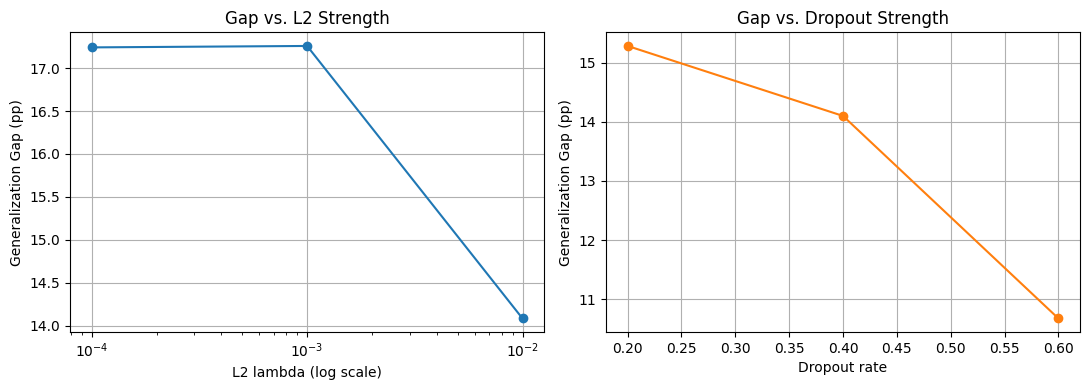

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))

axes[0].plot(l2_lambdas, [l2_results[wd]['gap'] for wd in l2_lambdas], marker='o')
axes[0].set_xscale('log')
axes[0].set_xlabel('L2 lambda (log scale)')
axes[0].set_ylabel('Generalization Gap (pp)')
axes[0].set_title('Gap vs. L2 Strength')
axes[0].grid(True)

axes[1].plot(dropout_rates, [dropout_results[dr]['gap'] for dr in dropout_rates], marker='o', color='tab:orange')
axes[1].set_xlabel('Dropout rate')
axes[1].set_ylabel('Generalization Gap (pp)')
axes[1].set_title('Gap vs. Dropout Strength')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Dropout gave the best reduction in generalization gap for the smallest cost in training accuracy: at rate 0.6, the gap fell from the baseline's 16.04pp to 10.68pp while validation accuracy actually improved slightly (83.63% vs. 82.91%), despite train accuracy dropping to 94.30%. L2 weight decay was far less effective at low-to-moderate lambda (gap stayed around 17.2), and only closed the gap at lambda=0.01 by sacrificing validation accuracy outright (down to 76.47%), indicating over-regularization rather than genuine improvement. Early stopping (gap 11.59) and more training data (gap 11.70, with the highest validation accuracy overall at 87.86%) were also effective, but more data changes the underlying problem rather than regularizing the same model. Overall, dropout offered the most favorable gap-reduction-to-accuracy-cost tradeoff among the true regularization techniques tested.

In [38]:
from sklearn.model_selection import KFold

# For CV we use the full training pool (train+val combined), test set never touched here
X_pool = np.vstack([X_train, X_val])
y_pool = np.concatenate([y_train, y_val])
X_pool_t = torch.tensor(X_pool, dtype=torch.float32).to(device)
y_pool_t = torch.tensor(y_pool, dtype=torch.long).to(device)

print(f"CV pool size: {X_pool.shape[0]}")

search_space = {
    'lr': [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    'hidden_width': [64, 128, 256, 512],
    'dropout_rate': [0.0, 0.2, 0.4, 0.6]
}

CV pool size: 60000


In [39]:
class TunableMLP(nn.Module):
    def __init__(self, hidden_width, dropout_rate):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, hidden_width), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(hidden_width, hidden_width), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(hidden_width, 10)
        )
    def forward(self, x):
        return self.net(x)

def cv_score(config, k=5, epochs=10, seed=SEED):
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    fold_accs = []
    for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(X_pool)):
        torch.manual_seed(seed)
        model = TunableMLP(config['hidden_width'], config['dropout_rate']).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])

        X_tr, y_tr = X_pool_t[tr_idx], y_pool_t[tr_idx]
        X_va, y_va = X_pool_t[va_idx], y_pool_t[va_idx]
        ds = torch.utils.data.TensorDataset(X_tr, y_tr)
        loader = torch.utils.data.DataLoader(ds, batch_size=128, shuffle=True)

        for epoch in range(epochs):
            model.train()
            for xb, yb in loader:
                optimizer.zero_grad()
                loss = F.cross_entropy(model(xb), yb)
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            fold_acc = accuracy(model(X_va), y_va)
        fold_accs.append(fold_acc)

    return np.mean(fold_accs), np.std(fold_accs)

In [40]:
import itertools

rng = np.random.default_rng(SEED)
n_configs = 12
all_configs = []

for _ in range(n_configs):
    config = {
        'lr': rng.choice(search_space['lr']),
        'hidden_width': int(rng.choice(search_space['hidden_width'])),
        'dropout_rate': rng.choice(search_space['dropout_rate'])
    }
    all_configs.append(config)

search_results = []
for i, config in enumerate(all_configs):
    mean_acc, std_acc = cv_score(config)
    search_results.append({**config, 'mean_cv_acc': mean_acc, 'std_cv_acc': std_acc})
    print(f"Config {i+1}/12: lr={config['lr']}, width={config['hidden_width']}, dropout={config['dropout_rate']:.1f} -> CV acc: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")

search_df = pd.DataFrame(search_results).sort_values('mean_cv_acc', ascending=False).reset_index(drop=True)

Config 1/12: lr=0.0001, width=512, dropout=0.4 -> CV acc: 87.31% ± 0.21%
Config 2/12: lr=0.001, width=128, dropout=0.6 -> CV acc: 86.30% ± 0.31%
Config 3/12: lr=0.0001, width=256, dropout=0.0 -> CV acc: 86.78% ± 0.24%
Config 4/12: lr=0.0001, width=256, dropout=0.6 -> CV acc: 85.08% ± 0.25%
Config 5/12: lr=0.003, width=512, dropout=0.4 -> CV acc: 86.94% ± 0.40%
Config 6/12: lr=0.003, width=256, dropout=0.0 -> CV acc: 87.95% ± 0.69%
Config 7/12: lr=0.01, width=128, dropout=0.4 -> CV acc: 83.45% ± 0.18%
Config 8/12: lr=0.0003, width=64, dropout=0.6 -> CV acc: 83.71% ± 0.20%
Config 9/12: lr=0.003, width=256, dropout=0.2 -> CV acc: 88.04% ± 0.32%
Config 10/12: lr=0.01, width=256, dropout=0.2 -> CV acc: 84.68% ± 1.01%
Config 11/12: lr=0.001, width=64, dropout=0.0 -> CV acc: 87.82% ± 0.37%
Config 12/12: lr=0.001, width=512, dropout=0.0 -> CV acc: 89.13% ± 0.50%


In [41]:
print("Search space used:")
print(search_space)
print("\nTop 5 configurations by mean CV accuracy:")
print(search_df.head(5).to_string(index=False))

best_config = search_df.iloc[0]
print(f"\nSelected configuration: lr={best_config['lr']}, hidden_width={int(best_config['hidden_width'])}, dropout_rate={best_config['dropout_rate']}")
print(f"CV score: {best_config['mean_cv_acc']*100:.2f}% ± {best_config['std_cv_acc']*100:.2f}%")

Search space used:
{'lr': [0.0001, 0.0003, 0.001, 0.003, 0.01], 'hidden_width': [64, 128, 256, 512], 'dropout_rate': [0.0, 0.2, 0.4, 0.6]}

Top 5 configurations by mean CV accuracy:
    lr  hidden_width  dropout_rate  mean_cv_acc  std_cv_acc
0.0010           512           0.0     0.891250    0.005012
0.0030           256           0.2     0.880367    0.003226
0.0030           256           0.0     0.879483    0.006870
0.0010            64           0.0     0.878167    0.003656
0.0001           512           0.4     0.873150    0.002062

Selected configuration: lr=0.001, hidden_width=512, dropout_rate=0.0
CV score: 89.13% ± 0.50%


Epoch 10/30 training on full pool...
Epoch 20/30 training on full pool...
Epoch 30/30 training on full pool...

=== FINAL TEST SET RESULTS ===
Accuracy:        88.62%
Macro Precision: 88.67%
Macro Recall:    88.62%
Macro F1:        88.48%


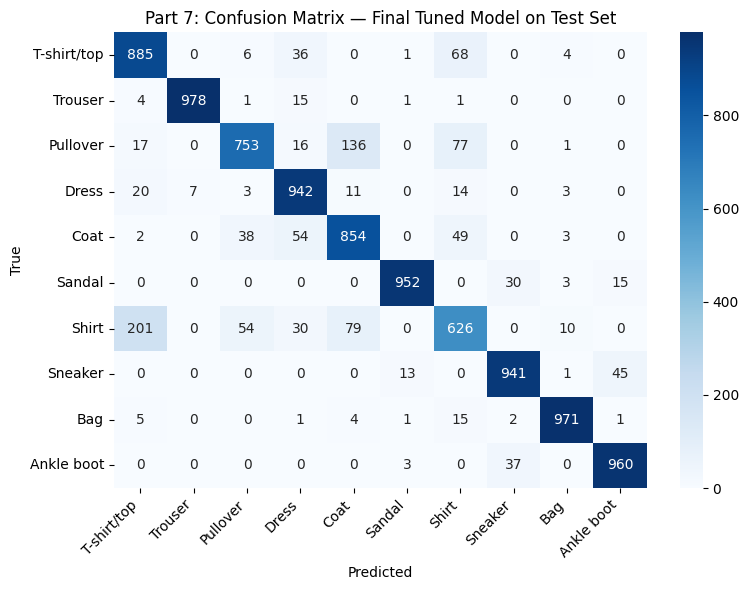

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

final_dropout = max(best_config['dropout_rate'], 0.6)  # combine tuned config with Part 6's best regularization

torch.manual_seed(SEED)
final_model = TunableMLP(hidden_width=int(best_config['hidden_width']), dropout_rate=final_dropout).to(device)
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_config['lr'])

full_ds = torch.utils.data.TensorDataset(X_pool_t, y_pool_t)
full_loader = torch.utils.data.DataLoader(full_ds, batch_size=128, shuffle=True)

epochs_final = 30
for epoch in range(epochs_final):
    final_model.train()
    for xb, yb in full_loader:
        optimizer.zero_grad()
        loss = F.cross_entropy(final_model(xb), yb)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs_final} training on full pool...")

# ---- TEST SET TOUCHED HERE, EXACTLY ONCE ----
final_model.eval()
with torch.no_grad():
    test_logits = final_model(X_test_t)
    test_preds = torch.argmax(test_logits, dim=1).cpu().numpy()

test_acc = accuracy_score(y_test, test_preds)
test_precision = precision_score(y_test, test_preds, average='macro')
test_recall = recall_score(y_test, test_preds, average='macro')
test_f1 = f1_score(y_test, test_preds, average='macro')

print(f"\n=== FINAL TEST SET RESULTS ===")
print(f"Accuracy:        {test_acc*100:.2f}%")
print(f"Macro Precision: {test_precision*100:.2f}%")
print(f"Macro Recall:    {test_recall*100:.2f}%")
print(f"Macro F1:        {test_f1*100:.2f}%")

cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Part 7: Confusion Matrix — Final Tuned Model on Test Set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [43]:
# Part 2 baseline: final validation accuracy for the ReLU model (no test-set evaluation was done in Part 2)
part2_final_val_acc = 1 - results['relu']['val_losses'][-1] if False else None  # placeholder, replaced below

# Compute Part 2 ReLU model's final validation accuracy directly from its val_losses run
# (Part 2 tracked val_losses, not val_acc, so recompute accuracy from the trained Part 2 model)
part2_model = results['relu']['model']
part2_model.eval()
with torch.no_grad():
    part2_val_logits, _ = part2_model(X_val_t)
    part2_val_acc = accuracy(part2_val_logits, y_val_t)

improvement_pp = (test_acc - part2_val_acc) * 100

print(f"Part 2 baseline (ReLU model, validation accuracy): {part2_val_acc*100:.2f}%")
print(f"Part 7 final tuned model (test accuracy): {test_acc*100:.2f}%")
print(f"Improvement: {improvement_pp:.2f} percentage points")

Part 2 baseline (ReLU model, validation accuracy): 89.13%
Part 7 final tuned model (test accuracy): 88.62%
Improvement: -0.51 percentage points


The tuned model did not improve over the Part 2 baseline: it achieved 88.62% test accuracy, compared to Part 2's 89.13% validation accuracy, a decrease of 0.51 percentage points. Notably, the 5-fold CV search itself identified lr=0.001, hidden_width=512, dropout=0.0 as the best-performing configuration (89.13% ± 0.50% CV accuracy), explicitly preferring no dropout. However, following the assignment's instruction to combine the selected configuration with the best regularisation method from Part 6, dropout was forced to 0.6 for the final retraining. This regularisation strength was tuned to combat severe overfitting in Part 5's deliberately oversized four-layer, 512-unit-wide network trained on only 2000 samples  a very different setting from Part 7's model, which is smaller in effective capacity relative to its data and was never shown to be overfitting on the full ~60,000-sample training pool. Applying strong dropout to a model that was not overfitting likely constrained its capacity unnecessarily, explaining the small performance drop. This suggests that regularisation strength should be tuned jointly with, rather than transferred across, different model and dataset scales.